Epoch 0, Loss: 1.0014368295669556, Alpha: 1.000990629196167
Epoch 500, Loss: 0.00134395738132298, Alpha: 0.8903003334999084
Epoch 1000, Loss: 0.0007815914577804506, Alpha: 0.8580510020256042
Epoch 1500, Loss: 0.0005083799478597939, Alpha: 0.8282753229141235
Epoch 2000, Loss: 0.00035732428659684956, Alpha: 0.8003630638122559
Epoch 2500, Loss: 0.00026631125365383923, Alpha: 0.7738450169563293
Epoch 3000, Loss: 0.00020570779452100396, Alpha: 0.7482345104217529
Epoch 3500, Loss: 0.00016455880540888757, Alpha: 0.7226700782775879
Epoch 4000, Loss: 0.00031933787977322936, Alpha: 0.6978934407234192
Epoch 4500, Loss: 0.00011022688704542816, Alpha: 0.6726669669151306
4/4 [==============================] - 0s 2ms/step


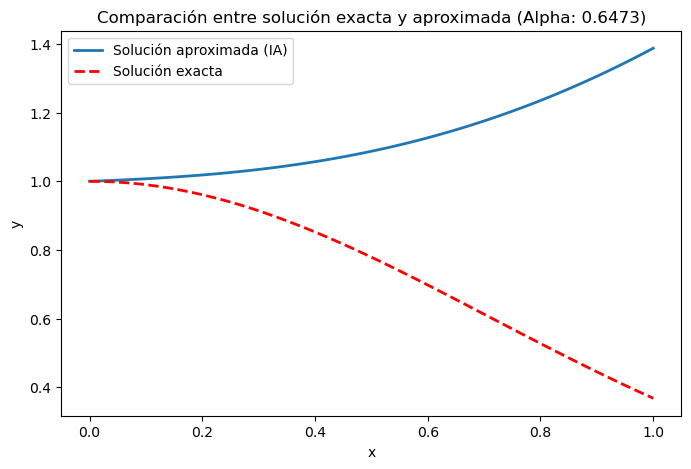

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Definir el parámetro desconocido alpha como una variable entrenable
alpha = tf.Variable(1.0, dtype=tf.float32, trainable=True)

# Definir la ecuación diferencial dy/dx = alpha * x / y
def ode(x, y):
    return alpha * x * y

# Definir la red neuronal
model = tf.keras.Sequential([ 
    tf.keras.layers.Dense(40, activation='tanh', input_shape=(1,)),
    tf.keras.layers.Dense(40, activation='tanh'),
    tf.keras.layers.Dense(40, activation='tanh'),
    tf.keras.layers.Dense(1)
])

# Función de pérdida basada en la ecuación diferencial
def custom_loss(x):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)  # Salida de la red neuronal
    dy_dx = tape.gradient(y_pred, x)  # Derivada de la red respecto a x
    return tf.reduce_mean(tf.square(dy_dx - ode(x, y_pred)))  # Minimizar el error

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Datos de entrenamiento
x_train = np.linspace(0.1, 1, 100).reshape(-1, 1).astype(np.float32)  # Evitar x=0
x_train = tf.Variable(x_train)

# Condición inicial y(0) = 1
x_0 = tf.convert_to_tensor([[0.0]], dtype=tf.float32)
y_0 = tf.convert_to_tensor([[1.0]], dtype=tf.float32)

# Función de entrenamiento personalizada
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        loss_value = custom_loss(x_train)
        # Penalización por la condición inicial
        y_pred_0 = model(x_0)
        loss_value += tf.reduce_mean(tf.square(y_pred_0 - y_0))
    
    grads = tape.gradient(loss_value, model.trainable_variables + [alpha])
    optimizer.apply_gradients(zip(grads, model.trainable_variables + [alpha]))
    return loss_value

# Entrenamiento manual
epochs = 5000
for epoch in range(epochs):
    loss = train_step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}, Alpha: {alpha.numpy()}")

# Predecir la solución
x_test = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)
y_pred = model.predict(x_test)

# Graficar la solución
plt.figure(figsize=(8, 5))
plt.plot(x_test, y_pred, label='Solución aproximada (IA)', linestyle='-', linewidth=2)
plt.plot(x_test, np.exp(-x_test**2), label='Solución exacta', linestyle='--', linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'Comparación entre solución exacta y aproximada (Alpha: {alpha.numpy():.4f})')
plt.show()

Epoch 0, Loss: 1.769627, Alpha: 0.990000
Epoch 500, Loss: 0.000122, Alpha: 0.075333
Epoch 1000, Loss: 0.000033, Alpha: 0.051306
Epoch 1500, Loss: 0.000011, Alpha: 0.037838
Epoch 2000, Loss: 0.000003, Alpha: 0.028986
Epoch 2500, Loss: 0.000001, Alpha: 0.023289
Epoch 3000, Loss: 0.000000, Alpha: 0.020150
Epoch 3500, Loss: 0.000000, Alpha: 0.018805
Epoch 4000, Loss: 0.000000, Alpha: 0.018360
Epoch 4500, Loss: 0.000000, Alpha: 0.018154
Valor estimado de alpha: 0.017713


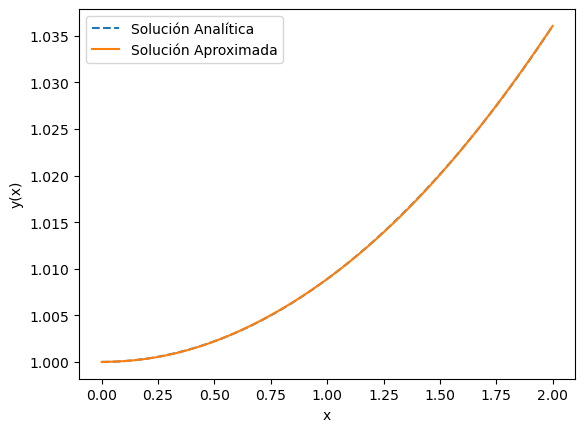

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Definir el parámetro alpha como una variable entrenable
alpha = tf.Variable(1.0, dtype=tf.float32, trainable=True)  # Inicialización arbitraria

# Crear una red neuronal simple para aproximar y(x)
class NeuralNetwork(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(10, activation="tanh")
        self.dense2 = tf.keras.layers.Dense(10, activation="tanh")
        self.dense3 = tf.keras.layers.Dense(1)  # Salida escalar
    
    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.dense3(x)

# Instanciar la red neuronal
model = NeuralNetwork()

# Definir la función de pérdida basada en la ecuación diferencial
def loss_fn(x):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)
    dy_dx = tape.gradient(y_pred, x)  # Calcular dy/dx
    residual = dy_dx - alpha * x * y_pred  # Ecuación diferencial
    ic_loss = (model(tf.zeros((1, 1))) - 1.0) ** 2  # Condición inicial: y(0) = 1
    return tf.reduce_mean(tf.square(residual)) + ic_loss  # Minimizar error cuadrático

# Optimizador
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Entrenamiento
x_train = tf.convert_to_tensor(np.linspace(0, 2, 100).reshape(-1, 1), dtype=tf.float32)
n_epochs = 5000

for epoch in range(n_epochs):
    with tf.GradientTape() as tape:
        loss = loss_fn(x_train)
    grads = tape.gradient(loss, model.trainable_variables + [alpha])
    optimizer.apply_gradients(zip(grads, model.trainable_variables + [alpha]))
    
    if epoch % 500 == 0:
        #print(f"Epoch {epoch}, Loss: {loss.numpy():.6f}, Alpha: {alpha.numpy():.6f}")
        print(f"Epoch {epoch}, Loss: {loss.numpy().item():.6f}, Alpha: {alpha.numpy().item():.6f}")


# Mostrar el valor final de alpha
print(f"Valor estimado de alpha: {alpha.numpy():.6f}")



# Graficar la solución aproximada
x_test = np.linspace(0, 2, 100).reshape(-1, 1)
y_pred = model(tf.convert_to_tensor(x_test, dtype=tf.float32)).numpy()

plt.plot(x_test, np.exp(alpha.numpy() / 2 * x_test**2), label="Solución Analítica", linestyle='dashed')
plt.plot(x_test, y_pred, label="Solución Aproximada")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.show()
